In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
data = {
    'level_karakter': [10, 20, 30, 40, 50, 60, 60, 60, 60, 60],
    'level_resonate': [5, 5, 7, 9, 10, 10, 11, 12, 13, 15],
    'level_psycube': [40, 40, 50, 50, 60, 60, 60, 60, 60, 60],
    'damage_ultimate': [12000, 14500, 18000, 22000, 26000, 28000, 31000, 35000, 39000, 46000]
}

df = pd.DataFrame(data)
print(df)

   level_karakter  level_resonate  level_psycube  damage_ultimate
0              10               5             40            12000
1              20               5             40            14500
2              30               7             50            18000
3              40               9             50            22000
4              50              10             60            26000
5              60              10             60            28000
6              60              11             60            31000
7              60              12             60            35000
8              60              13             60            39000
9              60              15             60            46000


In [ ]:
# Menentukan variabel
x = df[['level_karakter', 'level_resonate', 'level_psycube']]
y = df['damage_ultimate']

In [ ]:
# Split data train dan test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=82
)

In [ ]:
# Membuat model regresi
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Melihat atau menghitung koefisien
print("Intercept (a):", model.intercept_)
print("Koefisien (Karakter, Resonate, Psycube):", model.coef_)

Intercept (a): -6701.906412478376
Koefisien (Karakter, Resonate, Psycube): [ -55.11265165 3778.16291161  -13.6915078 ]


In [ ]:
y_pred = model.predict(x_test)

print("Nilai prediksi:", y_pred)
print("Nilai Asli:", y_test.values)

Nilai prediksi: [10538.99480069 30729.63604853]
Nilai Asli: [14500 31000]


In [ ]:
# Evaluasi model
print("Mean Absolute Error (MAE):", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squeare Error (MSE):", metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squeare Error (RMSE):", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error (MAE): 2115.6845753899543
Mean Squeare Error (MSE): 7881329.427595737
Root Mean Squeare Error (RMSE): 2807.370554023059


/tmp/ipykernel_11661/4098365746.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


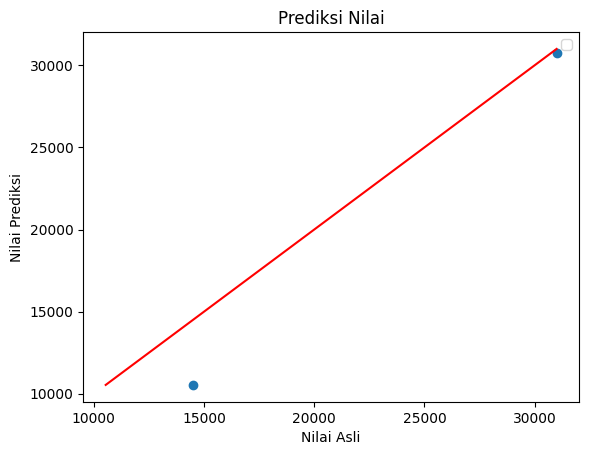

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Nilai Asli")
plt.ylabel("Nilai Prediksi")
plt.title("Prediksi Nilai")
plt.legend()
plt.show()

In [ ]:
data_baru = [[60, 10, 50]]
prediksi_damage = model.predict(data_baru)
print("Prediksi Damage Ultimate:", prediksi_damage)

Prediksi Damage Ultimate: [27088.3882149]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Analisis:

Dari output koefisien model sebesar [-55.11, 3778.16, -13.69], dapat dilihat kalau variabel ke-2 (Level Resonate) memiliki bobot pengaruh yang paling dominan terhadap lonjakan Damage Ultimate dibandingkan level karakter dasar. Prediksi untuk data testing juga tergolong representatif dengan garis visual berwarna merah yang menunjukkan tren prediksi nilai sejajar dengan nilai asli.